In [ ]:
from sklearn.datasets import fetch_california_housing # :)
import pandas as pd
import numpy as np

data = fetch_california_housing(as_frame=True)
df = data.frame

In [ ]:
#un ejemplo de un método de pandas útil para explorar el dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
# Mostrar las primeras 5 filas
print(df.head())

# Mostrar las últimas 5 filas
print(df.tail())

# Descripción estadística de los datos
print(df.describe())

# Información general del DataFrame
print(df.info())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.

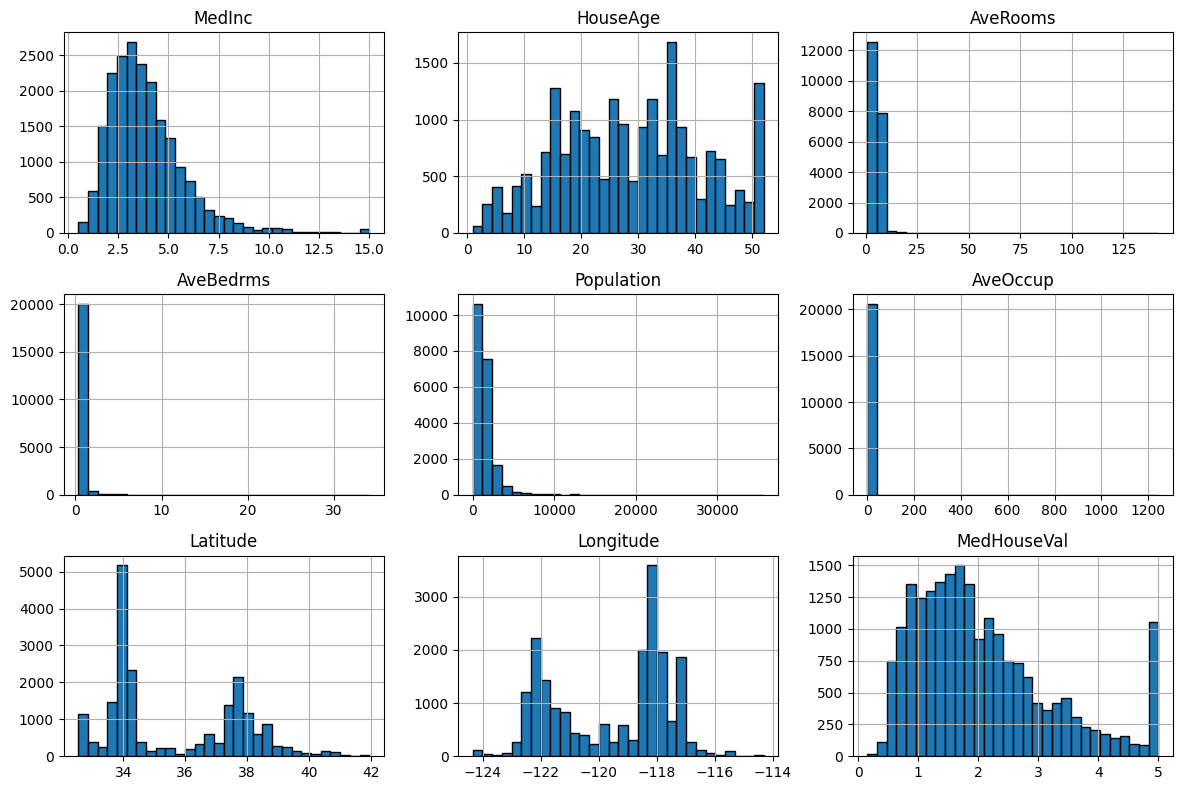

In [ ]:
import matplotlib.pyplot as plt

# Crear histogramas de todas las variables
df.hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

# Mezclar y dividir el dataset
df_train, df_test = train_test_split(df, test_size=0.1, random_state=42)

# Imprimir las dimensiones de cada subconjunto
print("Dimensiones del conjunto de entrenamiento:", df_train.shape)
print("Dimensiones del conjunto de prueba:", df_test.shape)


Dimensiones del conjunto de entrenamiento: (18576, 9)
Dimensiones del conjunto de prueba: (2064, 9)


             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  1.857600e+04  1.857600e+04  1.857600e+04  1.857600e+04  1.857600e+04   
mean  -1.069104e-16  1.337814e-16  1.421009e-16  2.054056e-16  3.213049e-17   
std    1.000027e+00  1.000027e+00  1.000027e+00  1.000027e+00  1.000027e+00   
min   -1.782910e+00 -2.192051e+00 -1.824822e+00 -1.575043e+00 -1.249298e+00   
25%   -6.916826e-01 -8.424365e-01 -3.923809e-01 -1.872048e-01 -5.615094e-01   
50%   -1.741902e-01  3.084362e-02 -7.840397e-02 -9.903561e-02 -2.281423e-01   
75%    4.673101e-01  6.659565e-01  2.481628e-01  5.800589e-03  2.622583e-01   
max    5.881793e+00  1.856793e+00  5.429988e+01  6.799934e+01  3.005124e+01   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  1.857600e+04  1.857600e+04  1.857600e+04  1.857600e+04  
mean   3.136547e-17 -1.156697e-15 -5.159620e-15  1.836028e-17  
std    1.000027e+00  1.000027e+00  1.000027e+00  1.000027e+00  
min   -2.187729e-01 -1.445867e+0

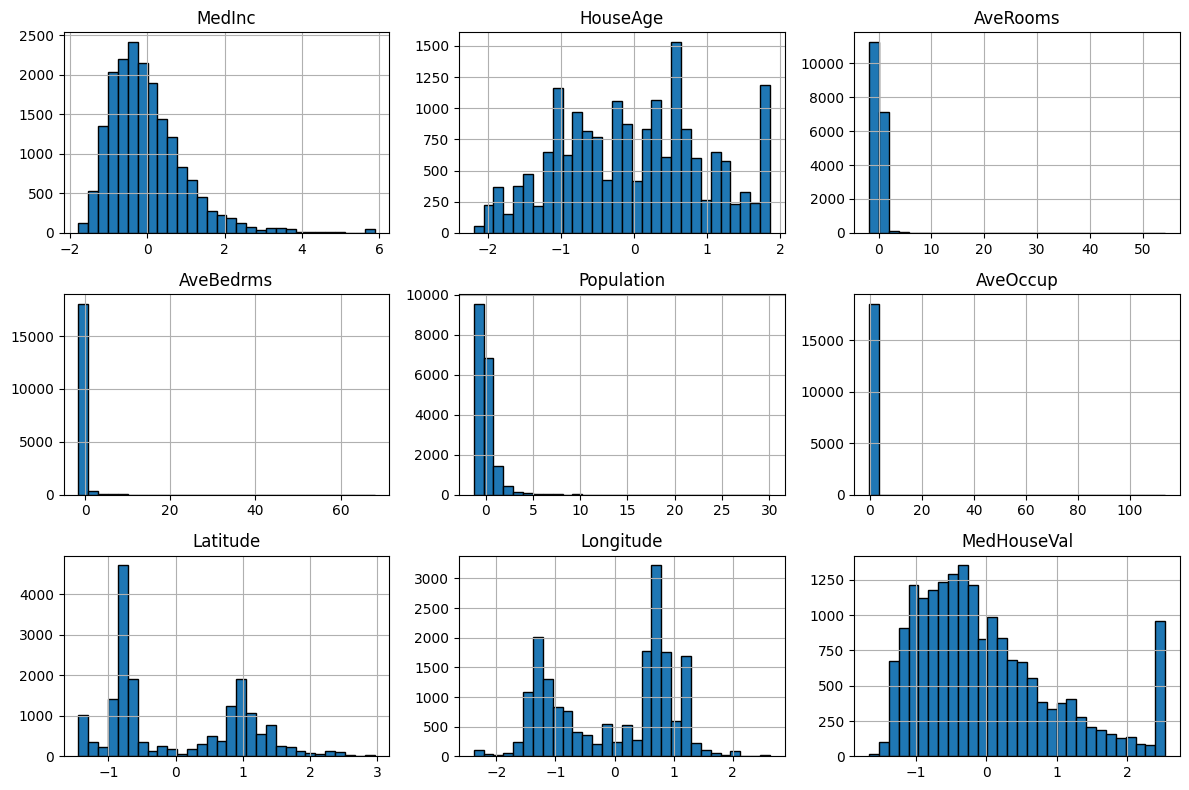

In [ ]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Crear el escalador y ajustarlo al conjunto de entrenamiento
scaler = StandardScaler()
df_train_norm = pd.DataFrame(scaler.fit_transform(df_train), columns=df_train.columns)
df_test_norm = pd.DataFrame(scaler.transform(df_test), columns=df_test.columns)

# Verificar que los datos han sido normalizados
print(df_train_norm.describe())

# Generar histogramas de las variables X e Y en el conjunto de entrenamiento normalizado
df_train_norm.hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()


In [ ]:
# Extraer variables X (características) y Y (objetivo) para entrenamiento y prueba
train_x = df_train_norm.drop(columns=["MedHouseVal"]).values  # Matriz de características
train_y = df_train_norm["MedHouseVal"].values  # Vector objetivo

test_x = df_test_norm.drop(columns=["MedHouseVal"]).values
test_y = df_test_norm["MedHouseVal"].values

# Imprimir dimensiones de los nuevos arrays
print("Dimensiones de train_x:", train_x.shape)
print("Dimensiones de train_y:", train_y.shape)
print("Dimensiones de test_x:", test_x.shape)
print("Dimensiones de test_y:", test_y.shape)


Dimensiones de train_x: (18576, 8)
Dimensiones de train_y: (18576,)
Dimensiones de test_x: (2064, 8)
Dimensiones de test_y: (2064,)


In [ ]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.layers import Activation
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
from tensorflow.keras import initializers

np.random.seed(1)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

def architecture(n_hidden1, n_hidden2, initializer, activation, input_shape):
    model = Sequential()

    # Capa de entrada
    model.add(Input(shape=input_shape))

    # Primera capa oculta
    model.add(Dense(units=n_hidden1,
                    kernel_initializer=initializer,
                    bias_initializer='zeros',
                    activation=activation))

    # Segunda capa oculta
    model.add(Dense(units=n_hidden2,
                    kernel_initializer=initializer,
                    bias_initializer='zeros',
                    activation=activation))

    # Capa de salida
    model.add(Dense(units=1,
                    kernel_initializer=initializer,
                    bias_initializer='zeros',
                    activation='linear'))  # 'linear' porque es un problema de regresión

    return model
    model = architecture(n_hidden1=64, n_hidden2=32, initializer='he_normal', activation='relu', input_shape=(8,))
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,925 (7.52 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,284 (5.02 KB)

Epoch 1/100
581/581 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4989 - mean_absolute_error: 0.5744 - val_loss: 0.5072 - val_mean_absolute_error: 0.5767
Epoch 2/100
581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4897 - mean_absolute_error: 0.5711 - val_loss: 0.5093 - val_mean_absolute_error: 0.5834
Epoch 3/100
581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4987 - mean_absolute_error: 0.5765 - val_loss: 0.5092 - val_mean_absolute_error: 0.5794
Epoch 4/100
581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4996 - mean_absolute_error: 0.5767 - val_loss: 0.5165 - val_mean_absolute_error: 0.5863
Epoch 5/100
581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5036 - mean_absolute_error: 0.5793 - val_loss: 0.5245 - val_mean_absolute_error: 0.5958
Epoch 6/100
581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4895 - mean_absolute_error: 0.5727 - val_loss: 0.5110 - val_mean_absolute_error: 0.5758
Epoch 7/100
581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4992 - mean_absolute_error: 0.5

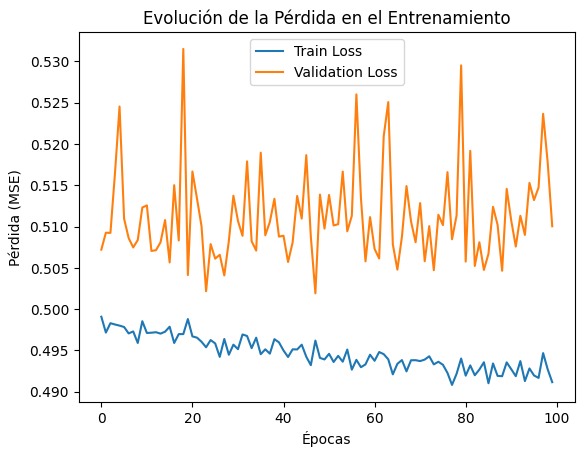

In [ ]:
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Compilación del modelo
model.compile(optimizer=Adam(learning_rate=0.01),  # Adam con tasa de aprendizaje de 0.01
              loss='mean_squared_error',
              metrics=['mean_absolute_error'])

# Entrenamiento del modelo
history = model.fit(train_x, train_y,
                    validation_data=(test_x, test_y),
                    epochs=100,
                    batch_size=32)

# Gráfica de la función de costo vs época
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.title('Evolución de la Pérdida en el Entrenamiento')
plt.show()


In [ ]:

test_loss, test_mae = model.evaluate(test_x, test_y)

print(f'Pérdida en el conjunto de prueba: {test_loss:.4f}')
print(f'Error Absoluto Medio (MAE): {test_mae:.4f}')


65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4955 - mean_absolute_error: 0.5738
Pérdida en el conjunto de prueba: 0.5100
Error Absoluto Medio (MAE): 0.5769


Epoch 1/100
581/581 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3949 - mean_absolute_error: 0.4598 - val_loss: 0.3007 - val_mean_absolute_error: 0.3922
Epoch 2/100
581/581 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2903 - mean_absolute_error: 0.3828 - val_loss: 0.2563 - val_mean_absolute_error: 0.3486
Epoch 3/100
581/581 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2507 - mean_absolute_error: 0.3533 - val_loss: 0.2490 - val_mean_absolute_error: 0.3461
Epoch 4/100
581/581 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2367 - mean_absolute_error: 0.3410 - val_loss: 0.2637 - val_mean_absolute_error: 0.3466
Epoch 5/100
581/581 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2303 - mean_absolute_error: 0.3372 - val_loss: 0.2232 - val_mean_absolute_error: 0.3188
Epoch 6/100
581/581 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2317 - mean_absolute_error: 0.3344 - val_loss: 0.2399 - val_mean_absolute_error: 0.3471
Epoch 7/100
581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2230 - mean_absolute_error: 0.3

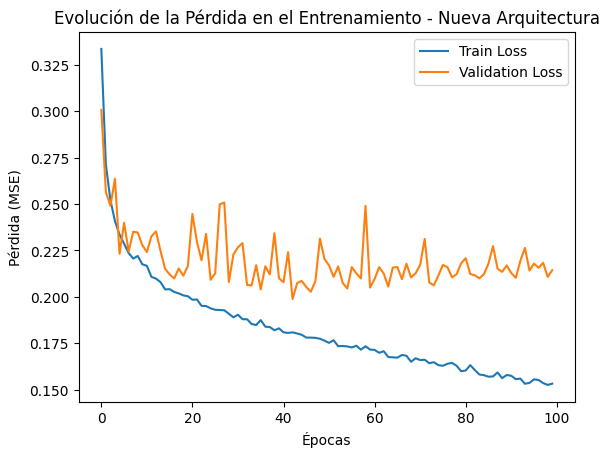

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1964 - mean_absolute_error: 0.3126
Pérdida en el conjunto de prueba: 0.2143
Error Absoluto Medio (MAE): 0.3199
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicción para el primer paciente con la nueva arquitectura: -1.2190


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import SGD

def new_architecture(n_hidden1, n_hidden2, n_hidden3, initializer, activation, input_shape):
    model = Sequential()

    # Capa de entrada
    model.add(Input(shape=input_shape))

    # Primera capa oculta
    model.add(Dense(units=n_hidden1,
                    kernel_initializer=initializer,
                    bias_initializer='zeros',
                    activation=activation))

    # Segunda capa oculta
    model.add(Dense(units=n_hidden2,
                    kernel_initializer=initializer,
                    bias_initializer='zeros',
                    activation=activation))

    # Tercera capa oculta
    model.add(Dense(units=n_hidden3,
                    kernel_initializer=initializer,
                    bias_initializer='zeros',
                    activation=activation))

    # Capa de salida
    model.add(Dense(units=1,
                    kernel_initializer=initializer,
                    bias_initializer='zeros',
                    activation='linear'))  # 'linear' para regresión

    return model
import matplotlib.pyplot as plt

# Creación del modelo con la nueva arquitectura
model2 = new_architecture(n_hidden1=128, n_hidden2=64, n_hidden3=32,
                          initializer='he_uniform', activation='tanh', input_shape=(8,))

# Compilación con SGD
model2.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),  # Momentum ayuda a suavizar el gradiente
               loss='mean_squared_error',
               metrics=['mean_absolute_error'])

# Entrenamiento del modelo
history2 = model2.fit(train_x, train_y,
                      validation_data=(test_x, test_y),
                      epochs=100,
                      batch_size=32)

# Gráfica de la función de costo vs época
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.title('Evolución de la Pérdida en el Entrenamiento - Nueva Arquitectura')
plt.show()
# Evaluación en el conjunto de prueba
test_loss2, test_mae2 = model2.evaluate(test_x, test_y)
print(f'Pérdida en el conjunto de prueba: {test_loss2:.4f}')
print(f'Error Absoluto Medio (MAE): {test_mae2:.4f}')

# Predicción para el primer paciente del conjunto de prueba
prediccion2 = model2.predict(test_x[:1])
print(f'Predicción para el primer paciente con la nueva arquitectura: {prediccion2[0][0]:.4f}')
